In [1]:
print("Name: Mikail Achmad")
print("ID Number: 24/542370/PA/23026")

Name: Mikail Achmad
ID Number: 24/542370/PA/23026


# 1. Face Mask Detection

In [2]:
pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=b6e57786b7ecb9deab75ecec9fa314548b590d2cb0f5b858c4dbc893a98a9887
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import wget
import zipfile

## Download and Extract Dataset

In [4]:
wget.download("https://drive.google.com/uc?export=download&id=1IMCE-y6zrE8j4ZE-JwlElN5bhQ8xf_Kf", "dataset.zip")

'dataset.zip'

In [5]:
zip_path = "dataset.zip"
extract_to = "./"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_to)

print("Selesai extract ke:", extract_to)

Selesai extract ke: ./


## Utility Functions

In [6]:
def load_image(image_path):
  image = cv2.imread(image_path)
  if image is None:
    print('Error: Could not load image.')
    return None, None
  Gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
  image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  return image, Gray

In [7]:
from skimage.feature import hog

# HOG / image params
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)

def extract_hog_features(image_gray):
  features, hog_image = hog(
      image_gray,
      orientations=ORIENTATIONS,
      pixels_per_cell=PIXELS_PER_CELL,
      cells_per_block=CELLS_PER_BLOCK,
      block_norm='L2-Hys',
      visualize=True,
      feature_vector=True
  )
  return features, hog_image

# Ganti ke LBP

In [8]:
def crop_half_image(img, bottom=True):
  h = img.shape[0]
  mid = h // 2
  if bottom:
    cropped = img[mid:, :]
  else:
    cropped = img[:mid, :]
  return cropped

## Feature Extraction (HOG) from Dataset

In [9]:
dataset_dir = 'dataset/'
IMAGE_SIZE = (64,64)
X = []
y = []
hog_img =[]
for root, dirs, files in os.walk(dataset_dir):
  print(root, dirs, files)
  for f in files:
    _, image_gray = load_image(os.path.join(root, f))
    img_crop = crop_half_image(image_gray, bottom=True)
    # jika crop menghasilkan area kosong atau sangat kecil, fallback ke citra penuh
    if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
      img_crop = image_gray # fallback
      # optional: print warning
      print(f"[WARN] Crop menghasilkan area kecil untuk {files}, menggunakan citra penuh.")
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    hog_feature, hog_maps = extract_hog_features(roi_resized)
    if hog_feature is None:
      continue
    hog_img.append(hog_maps)
    X.append(hog_feature)
    if root.split('/')[-1]=="without_mask":
      y.append(0)
    else:
      y.append(1)
# Move array conversion outside the loop
X = np.array(X)
y = np.array(y)
print(f"[INFO] Total sampel fitur: {X.shape[0]}, dimensi fitur: {X.shape[1]}")

dataset/ ['without_mask', 'with_mask'] []
dataset/without_mask [] ['0_0_dongchengpeng_0020.jpg', '0_0_caiyilin_0051.jpg', '0_0_chenhuilin_0018.jpg', '0_0_caiyilin_0024.jpg', '0_0_dongchengpeng_0001.jpg', '0_0_chenxuedong_0050.jpg', '0_0_anhu_0211.jpg', '0_0_anhu_0027.jpg', '0_0_jianailiang_0015.jpg', '0_0_guanyue_0083.jpg', '0_0_dongchengpeng_0042.jpg', '0_0_huangjinglun_0010.jpg', '0_0_fanyichen_0081.jpg', '0_0_caiyilin_0029.jpg', '0_0_chenhuilin_0096.jpg', '0_0_hanxue_0088.jpg', '0_0_fanyichen_0078.jpg', '0_0_hanxue_0010.jpg', '0_0_aidai_0074.jpg', '0_0_chenyao_0074.jpg', '0_0_huangjinglun_0008.jpg', '0_0_gulinazha_0082.jpg', '0_0_anhu_0098.jpg', '0_0_chenglong_0036.jpg', '0_0_huge_0029.jpg', '0_0_aidai_0043.jpg', '0_0_guanyue_0011.jpg', '0_0_caizhuoyan_0013.jpg', '0_0_chenyao_0016.jpg', '0_0_fanshiqi_0089.jpg', '0_0_baobeier_0140.jpg', '0_0_fanyichen_0011.jpg', '0_0_caizhuoyan_0065.jpg', '0_0_baibaihe_0236.jpg', '0_0_huge_0061.jpg', '0_0_fengjianyu_0072.jpg', '0_0_chenxiang_0006.jpg

> HOG berfokus pada bentuk dan struktur objek dengan menangkap distribusi arah orientasi tepi lokal pada suatu gambar. Ini berarti HOG mencari perubahan intensitas piksel dan arah perubahan tersebut.



## Prepare Data for SVM (Train-Test Split and Scaling)

In [10]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y )

## Visualize Sample HOG Features

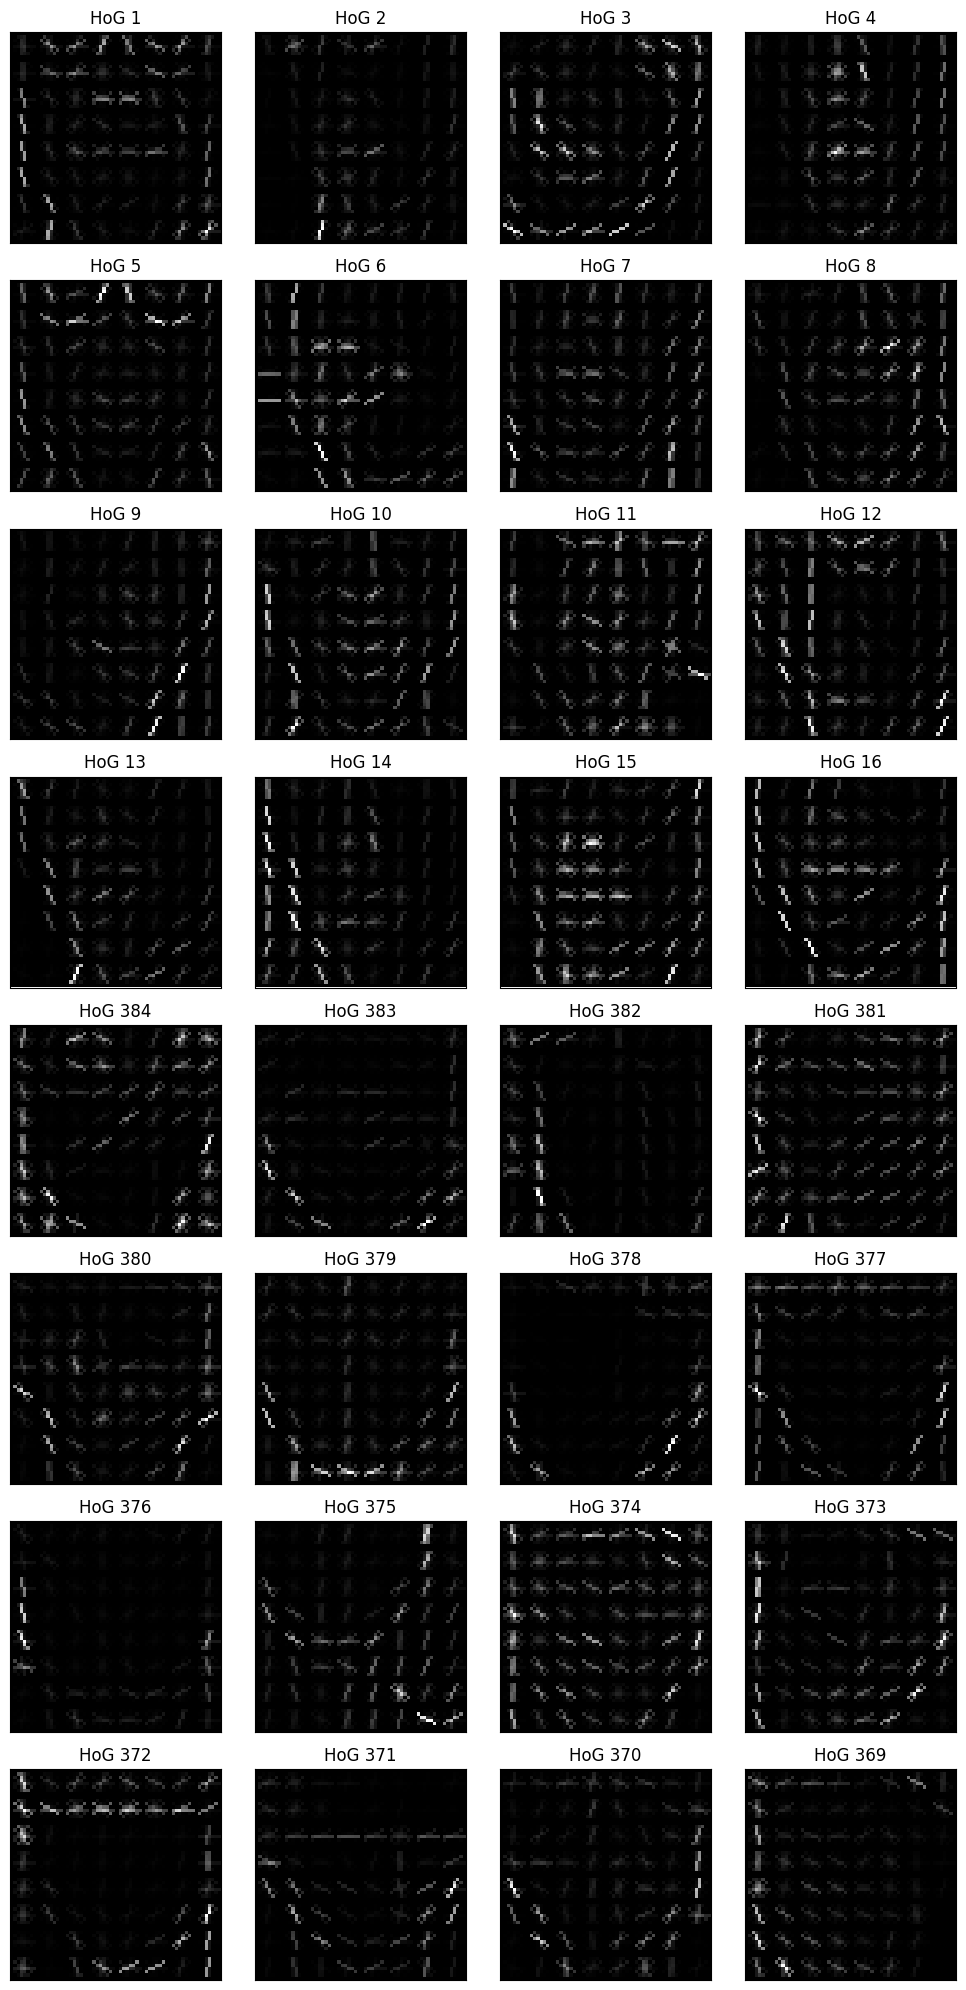

In [11]:
from skimage import exposure

ncol = 4
nrow = 8
fig, axes = plt.subplots(nrow, ncol, figsize=(10, 2.5*nrow),subplot_kw={'xticks':[], 'yticks':[]})
for i, ax in enumerate(axes.flat):
  if i < 16:
    temp =hog_img[i]
    hog_image = exposure.rescale_intensity(temp, in_range=(0, temp.max()))
    ax.imshow(hog_image, cmap='gray')
    ax.set_title(f'HoG {i+1}')
  else:
    temp =hog_img[len(hog_img) - (i)]
    hog_image = exposure.rescale_intensity(temp, in_range=(0, temp.max()))
    ax.imshow(hog_image, cmap='gray')
    ax.set_title(f'HoG {len(hog_img) - (i)}')

plt.tight_layout()
plt.show()

> Visualisasi HOG cenderung menampilkan garis patah yang menunjukkan tepi dan orientasi gradien, memberikan kesan seperti sketsa atau kerangka objek.

## Train SVM Model

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# scale fitur
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(x_test)

# training SVM (RBF)
clf = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
print("[INFO] Training SVM...")
clf.fit(X_train_s, y_train)

[INFO] Training SVM...


SVC(probability=True, random_state=42)

## Evaluate SVM Model

In [13]:
# evaluasi
y_pred = clf.predict(X_test_s)
print("\n[RESULT] Classification report:")
print(classification_report(y_test, y_pred, target_names=["without_mask","with_mask"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


[RESULT] Classification report:
              precision    recall  f1-score   support

without_mask       0.93      0.97      0.95        40
   with_mask       0.97      0.93      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80

Confusion Matrix:
[[39  1]
 [ 3 37]]


## Save Model and Scaler

In [14]:
import joblib
MODEL_PATH = "svm_mas_200_bottom_half.pkl"
# simpan model + scaler
joblib.dump({"model": clf,
             "scaler": scaler,
             "config": {"image_size" : IMAGE_SIZE,
                        "hog_params": {"orientations": ORIENTATIONS,
                                       "pixels_per_cell": PIXELS_PER_CELL,
                                       "cells_per_block": CELLS_PER_BLOCK},
                                       "crop": "bottom"}}, MODEL_PATH)
print(f"[INFO] Model tersimpan di: {MODEL_PATH}")

[INFO] Model tersimpan di: svm_mas_200_bottom_half.pkl


In [15]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [16]:
def detect_faces(image_gray, scale_factor=1.1, min_neighbors=5, min_size=(30, 30)):
  faces = face_cascade.detectMultiScale(
      image_gray,
      scaleFactor=scale_factor,
      minNeighbors=min_neighbors,
      minSize=min_size
  )
  return faces

In [17]:
def crop_faces(image_gray, faces, return_all=False):
  cropped_faces = []
  selected_faces = []
  if len(faces) > 0:
    if return_all:
      for x, y, w, h in faces:
        selected_faces.append((x, y, w, h))
        cropped_faces.append(image_gray[y:y+h, x:x+w])
    else:
      x, y, w, h = max(faces, key=lambda rect: rect[2] * rect[3])
      selected_faces.append((x, y, w, h))
      cropped_faces.append(image_gray[y:y+h, x:x+w])
  return cropped_faces, selected_faces

In [18]:
def feature_extraction_for_test(image_gray):
  features, hog_maps = [],[]
  faces = detect_faces(image_gray)
  cropped_face, _ = crop_faces(image_gray, faces)
  if cropped_face is None:
    print("wajah tidak terdeteksi..")
    return features, hog_maps
  else:
    img_crop = crop_half_image(cropped_face[0], bottom=True)
    # jika crop menghasilkan area kosong atau sangat kecil, fallback ke citra penuh
    if img_crop is None or img_crop.size == 0 or img_crop.shape[0]<4 or img_crop.shape[1]<4:
      img_crop = cropped_face[0] # fallback
      # optional: print warning
      print(f"[WARN] Crop menghasilkan area kecil untuk {files}, menggunakan citra penuh.")
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    features, hog_maps = extract_hog_features(roi_resized)
    features = np.array(features)
    features = features.reshape(1, -1)
    return features, hog_maps

In [19]:
import joblib
def predict_image(image, features, model_path):
  data = joblib.load(model_path)
  model_loaded = data.get("model")
  scaler = data.get("scaler")
  if scaler is not None:
    features = scaler.transform(features)
    pred = model_loaded.predict(features)[0]
    conf = None
    prob = 0
    prob = model_loaded.predict_proba(features)[0] if hasattr(model_loaded, "predict_proba") else None
    conf = float(max(prob))
    if pred == 1:
      label_str = "MASK"
    else:
      label_str = "NO MASK"
    print(f"Prediksi: {label_str}")
    return draw_result(image, conf, label_str)

In [20]:
def draw_text(image, label, score,
              font=cv2.FONT_HERSHEY_SIMPLEX,
              pos=(10, 30),
              font_scale=0.6,
              font_thickness=2,
              text_color=(255, 255, 255),
              text_color_bg=(0, 0, 255)
              ):
  x, y = pos
  score_text = f'Score: {score:.2f}'

  (w1, h1), _ = cv2.getTextSize(score_text, font, font_scale, font_thickness)
  (w2, h2), _ = cv2.getTextSize(label, font, font_scale, font_thickness)

  box_width = max(w1, w2) + 20
  box_height = h1 + h2 + 25

  # pastikan tidak keluar dari gambar (opsional)
  x = max(0, x)
  y = max(box_height, y)

  # background kotak
  cv2.rectangle(image,
   (x, y - box_height),
    (x + box_width, y),
                text_color_bg,
                -1)

  # tulis label
  cv2.putText(image, label, (x + 10, y - h1 - 10),
              font, font_scale, text_color, font_thickness)

  # tulis score
  cv2.putText(image, score_text, (x + 10, y - 10),
              font, font_scale, text_color, font_thickness)

def draw_result(image_bgr, score, label):
    result_image = image_bgr.copy()
    draw_text(result_image, label, score, pos=(10, 40))
    return result_image

Prediksi: MASK


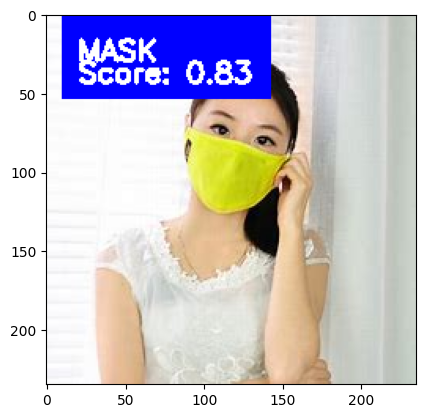

In [21]:
TESTING_IMAGE = "testing/mask1.png"
hog_feature, hog_maps = [],[]
image_rgb, image_gray = load_image(TESTING_IMAGE)
hog_feature, hog_maps = feature_extraction_for_test(image_gray)
result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)
plt.imshow(result_image)

# 2. Detection Using Video

In [22]:
import cv2
import joblib
from skimage.feature import hog

# ------- KONFIG -------
FACE_CASCADE = "haarcascade_frontalface_default.xml"
NOSE_CASCADE = "haarcascade_mcs_nose.xml"
MODEL_FILE = "svm_mask_200_bottom_half.pkl"
VIDEO_SRC = 0

IMAGE_SIZE = (64, 64)
HOG_PARAMS = dict(orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2),
                  block_norm='L2-Hys', visualize=False, feature_vector=True)

## Real-time Prediction Utility Functions

In [23]:
data = joblib.load(MODEL_FILE)
model = data.get("model")
scaler = data.get("scaler")

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + FACE_CASCADE)
nose_cascade = cv2.CascadeClassifier(NOSE_CASCADE)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [24]:
def extract_hog(img):
  return hog(img, **HOG_PARAMS).reshape(1, -1)

def predict_from_roi(roi_gray):
  roi = cv2.resize(roi_gray, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
  feat = extract_hog(roi)
  if scaler is not None:
    feat = scaler.transform(feat)
  pred = model.predict(feat)[0]
  conf = None
  if hasattr(model, "predict_proba"):
    conf = float(max(model.predict_proba(feat)[0]))
  return pred, conf

In [25]:
cap = cv2.VideoCapture(VIDEO_SRC)

In [26]:
while True:
  ret, frame = cap.read()
  if not ret:
    break

  if frame.shape[1] > 1280:
    scale = 1280 / frame.shape[1]
    frame = cv2.resize(frame, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(60,60))

  for (x,y,w,h) in faces:
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = frame[y:y+h, x:x+w]

    ny1 = int(h * 0.35); ny2 = int(h * 0.90)
    roi_nose = roi_gray[ny1:ny2, :]

    noses = nose_cascade.detectMultiScale(roi_nose, scaleFactor=1.1, minNeighbors=4, minSize=(20,20))

    half = h // 2
    roi_bottom = roi_gray[half:h, :]
    use_roi = roi_bottom if roi_bottom.size >= 64 else (roi_nose if roi_nose.size >= 64 else roi_gray)

    if len(noses) > 0:
      label = "NO MASK"
      color = (0,0,255)
      for (nx, ny, nw, nh) in noses:
        cv2.rectangle(roi_color, (nx, ny+ny1), (nx+nw, ny+ny1+nh), color, 1)
      else:
        pred, conf = predict_from_roi(use_roi)
        if pred == 1:
          label, color = "MASK", (0,255,0)
        else:
          label, color = "NO MASK", (0,0,255)
        if conf is not None:
          cv2.putTest(frame, f"{conf:.2f}", (x, y+h+18), cv2.FONT_HERSHY_SIMPLWX, 0.6, color, 2)

In [27]:
# ------- BACA VIDEO -------
cap = cv2.VideoCapture(VIDEO_SRC)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame.shape[1] > 1280:
        scale = 1280 / frame.shape[1]
        frame = cv2.resize(frame, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(60,60))

    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        ny1 = int(h * 0.35); ny2 = int(h * 0.90)
        roi_nose = roi_gray[ny1:ny2, :]

        noses = nose_cascade.detectMultiScale(roi_nose, scaleFactor=1.1, minNeighbors=4, minSize=(20,20))

        half = h // 2
        roi_bottom = roi_gray[half:h, :]
        use_roi = roi_bottom if roi_bottom.size >= 64 else (roi_nose if roi_nose.size >= 64 else roi_gray)


        if len(noses) > 0:
            label = "NO MASK"
            color = (0,0,255)
            for (nx, ny, nw, nh) in noses:
                cv2.rectangle(roi_color, (nx, ny+ny1), (nx+nw, ny+ny1+nh), color, 1)
        else:
            pred, conf = predict_from_roi(use_roi)
            if pred == 1:
                label, color = "MASK", (0,255,0)
            else:
                label, color = "NO MASK", (0,0,255)
            if conf is not None:
                cv2.putText(frame, f"{conf:.2f}", (x, y+h+18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        cv2.rectangle(frame, (x,y), (x+w, y+h), color, 2)
        cv2.putText(frame, label, (x, max(20, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.imshow("Mask Detect (minimal)", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# 3. Modify with LBP features


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import wget
import zipfile
from skimage.feature import hog, local_binary_pattern # local_binary_pattern added
from skimage import exposure
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Global configurations
IMAGE_SIZE = (64, 64)
# LBP parameters (NEW)
LBP_RADIUS = 3
LBP_N_POINTS = 8 * LBP_RADIUS # A common choice for uniform LBP

RANDOM_STATE = 42
MODEL_PATH = "lbp_mas_200_bottom_half_lbp.pkl" # Changed model name to reflect LBP
dataset_dir = 'dataset/'

In [29]:
def load_image(image_path):
  image = cv2.imread(image_path)
  if image is None:
    print(f'Error: Could not load image at {image_path}.')
    return None, None
  Gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
  image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  return image, Gray

def extract_lbp_features(image_gray):
  # Compute LBP image using 'uniform' method
  lbp_image = local_binary_pattern(image_gray, LBP_N_POINTS, LBP_RADIUS, method='uniform')
  # Compute histogram of the LBP image as the feature vector
  n_bins = int(lbp_image.max() + 1)
  hist, _ = np.histogram(lbp_image, density=True, bins=n_bins, range=(0, n_bins))
  return hist, lbp_image

def crop_half_image(img, bottom=True):
  h = img.shape[0]
  mid = h // 2
  if bottom:
    cropped = img[mid:, :]
  else:
    cropped = img[:mid, :]
  return cropped

In [30]:
X = []
y = []
lbp_img_samples = [] # To store a few LBP images for visualization (CHANGED from hog_img_samples)

print("Starting LBP feature extraction...") # Changed text
for root, dirs, files in os.walk(dataset_dir):
  for f in files:
    # Only process image files (e.g., .jpg, .png)
    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(root, f)
        _, image_gray = load_image(image_path)
        if image_gray is None:
            continue

        img_crop = crop_half_image(image_gray, bottom=True)
        # Fallback if cropping results in an empty or very small area
        if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
            img_crop = image_gray # fallback to full image

        roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
        lbp_feature, lbp_maps = extract_lbp_features(roi_resized) # Called LBP extraction function (CHANGED from hog_features)

        if lbp_feature is not None:
            X.append(lbp_feature)
            # Store a limited number of lbp maps for visualization
            if len(lbp_img_samples) < 32: # Store up to 32 samples for display
                lbp_img_samples.append(lbp_maps)

            # Assign label based on directory name
            if 'without_mask' in root:
                y.append(0)
            elif 'with_mask' in root:
                y.append(1)

X = np.array(X)
y = np.array(y)

print(f"[INFO] Total sampel fitur: {X.shape[0]}, dimensi fitur: {X.shape[1]}")

Starting LBP feature extraction...
[INFO] Total sampel fitur: 400, dimensi fitur: 26


> LBP berfokus pada tekstur lokal gambar,  membandingkan intensitas piksel pusat dengan intensitas piksel sekitar. Jika piksel tetangga lebih terang dari piksel pusat, ia diberi nilai '1'; jika lebih gelap, diberi nilai '0'. Serangkaian bit ini kemudian membentuk pola biner lokal yang merepresentasikan tekstur.

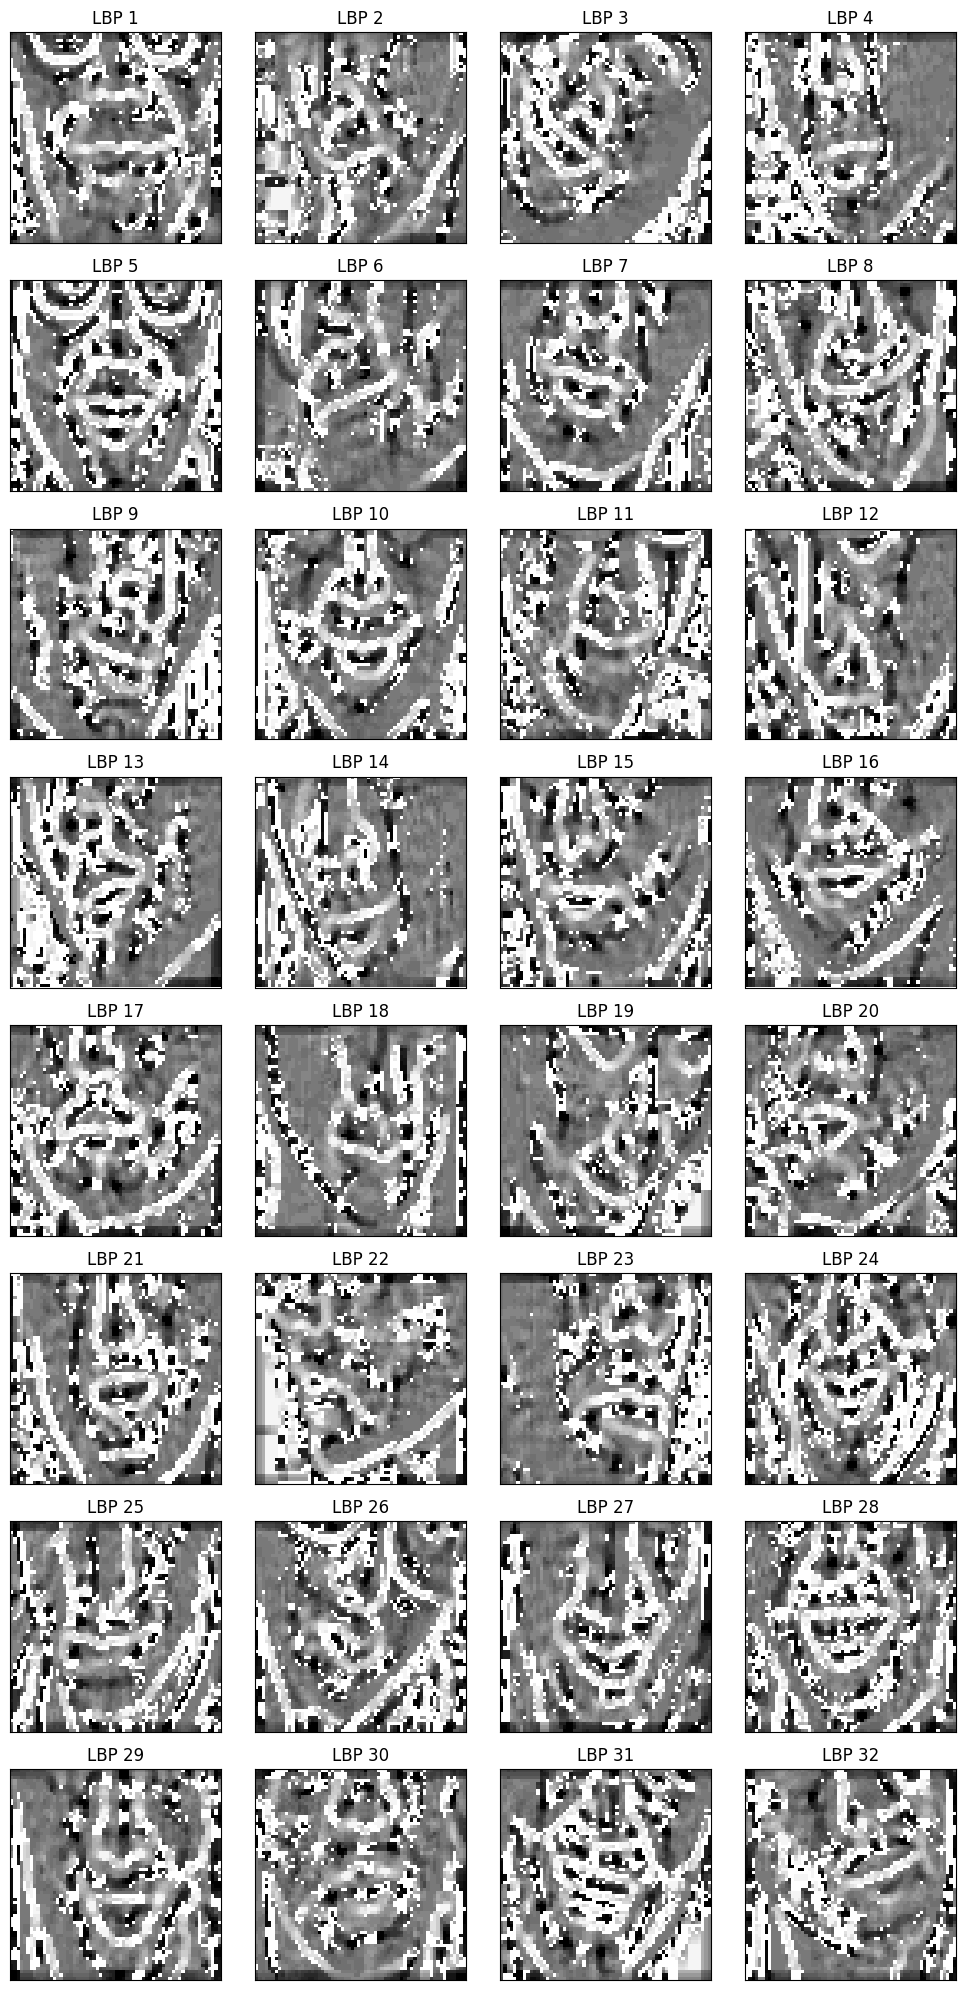

In [31]:
ncol = 4
nrow = 8
fig, axes = plt.subplots(nrow, ncol, figsize=(10, 2.5*nrow),subplot_kw={'xticks':[], 'yticks':[]})

for i, ax in enumerate(axes.flat):
  if i < len(lbp_img_samples):
    temp = lbp_img_samples[i]
    lbp_image_display = exposure.rescale_intensity(temp, in_range=(0, temp.max())) # Rescale for better visualization
    ax.imshow(lbp_image_display, cmap='gray') # Display LBP image
    ax.set_title(f'LBP {i+1}') # Changed title to LBP
  else:
    ax.set_visible(False) # Hide empty subplots if fewer than 32 samples

plt.tight_layout()
plt.show()

> Visualisasi LBP cenderung terlihat seperti gambar keabuan atau berbintik-bintik. Setiap piksel dalam gambar LBP merepresentasikan pola tekstur lokal, bukan arah tepi.

In [32]:
# Save the trained model and scaler
joblib.dump({"model": clf,
             "scaler": scaler,
             "config": {"image_size" : IMAGE_SIZE,
                        "lbp_params": {"radius": LBP_RADIUS, # Changed params to LBP
                                       "n_points": LBP_N_POINTS},
                                       "crop": "bottom"}}, MODEL_PATH)
print(f"[INFO] Model tersimpan di: {MODEL_PATH}")

[INFO] Model tersimpan di: lbp_mas_200_bottom_half_lbp.pkl


Prediksi: MASK


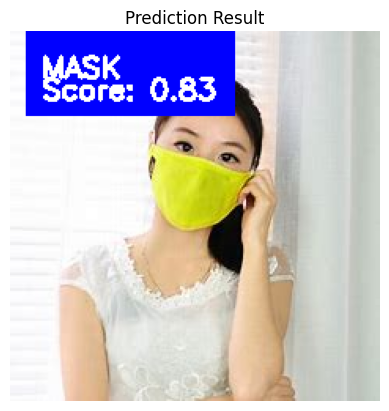

In [33]:
TESTING_IMAGE = "testing/mask1.png" # Ensure this image exists in your environment or provide a valid path

# Create a dummy 'testing' directory and an image if it doesn't exist for demonstration
if not os.path.exists('testing'):
    os.makedirs('testing')
    # Create a dummy image for testing if mask1.png doesn't exist
    if not os.path.exists(TESTING_IMAGE):
        dummy_image = np.zeros((100, 100, 3), dtype=np.uint8)
        cv2.putText(dummy_image, "Dummy", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        cv2.imwrite(TESTING_IMAGE, dummy_image)
        print(f"Created a dummy image at {TESTING_IMAGE} for testing.")

image_rgb, image_gray = load_image(TESTING_IMAGE)

if image_rgb is not None and image_gray is not None:
    lbp_feature, _ = feature_extraction_for_test(image_gray) # Changed from hog_feature
    result_image = predict_image(image_rgb, lbp_feature, MODEL_PATH)
    plt.imshow(result_image)
    plt.title("Prediction Result")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not load or process testing image: {TESTING_IMAGE}")

In [34]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_faces(image_gray, scale_factor=1.1, min_neighbors=5, min_size=(30, 30)):
  faces = face_cascade.detectMultiScale(
      image_gray,
      scaleFactor=scale_factor,
      minNeighbors=min_neighbors,
      minSize=min_size
  )
  return faces

def crop_faces(image_gray, faces, return_all=False):
  cropped_faces = []
  selected_faces = []
  if len(faces) > 0:
    if return_all:
      for x, y, w, h in faces:
        selected_faces.append((x, y, w, h))
        cropped_faces.append(image_gray[y:y+h, x:x+w])
    else:
      # Select the largest face if not returning all
      x, y, w, h = max(faces, key=lambda rect: rect[2] * rect[3])
      selected_faces.append((x, y, w, h))
      cropped_faces.append(image_gray[y:y+h, x:x+w])
  return cropped_faces, selected_faces

def feature_extraction_for_test(image_gray):
  features = []
  faces = detect_faces(image_gray)
  cropped_face_rois, _ = crop_faces(image_gray, faces)

  if not cropped_face_rois:
    print("wajah tidak terdeteksi..")
    return None, None
  else:
    # Assuming we are interested in the first (largest) detected face
    cropped_face = cropped_face_rois[0]

    img_crop = crop_half_image(cropped_face, bottom=True)
    # Fallback if cropping results in an empty or very small area
    if img_crop is None or img_crop.size == 0 or img_crop.shape[0]<4 or img_crop.shape[1]<4:
      img_crop = cropped_face # fallback to full face ROI

    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    lbp_feature, lbp_maps = extract_lbp_features(roi_resized) # Called LBP extraction function (CHANGED)

    if lbp_feature is None:
      return None, None

    features = np.array(lbp_feature).reshape(1, -1) # Reshaped LBP feature (CHANGED)
    return features, lbp_maps

def draw_text(image, label, score,
              font=cv2.FONT_HERSHEY_SIMPLEX,
              pos=(10, 30),
              font_scale=0.6,
              font_thickness=2,
              text_color=(255, 255, 255),
              text_color_bg=(0, 0, 255)
              ):
  x, y = pos
  score_text = f'Score: {score:.2f}'

  (w1, h1), _ = cv2.getTextSize(score_text, font, font_scale, font_thickness)
  (w2, h2), _ = cv2.getTextSize(label, font, font_scale, font_thickness)

  box_width = max(w1, w2) + 20
  box_height = h1 + h2 + 25

  # Ensure text box is within image bounds
  x = max(0, x)
  y = max(box_height, y)

  # Background rectangle for text
  cv2.rectangle(image,
                (x, y - box_height),
                (x + box_width, y),
                text_color_bg,
                -1)

  # Put label text
  cv2.putText(image, label, (x + 10, y - h1 - 10),
              font, font_scale, text_color, font_thickness)

  # Put score text
  cv2.putText(image, score_text, (x + 10, y - 10),
              font, font_scale, text_color, font_thickness)

def draw_result(image_bgr, score, label):
    result_image = image_bgr.copy()
    draw_text(result_image, label, score, pos=(10, 40))
    return result_image

def predict_image(image, features, model_path):
  if features is None or len(features) == 0:
    print("Tidak ada fitur untuk diprediksi.")
    return image

  data = joblib.load(model_path)
  model_loaded = data.get("model")
  scaler = data.get("scaler")

  if scaler is not None:
    features = scaler.transform(features)

  pred = model_loaded.predict(features)[0]
  conf = None
  prob = model_loaded.predict_proba(features)[0] if hasattr(model_loaded, "predict_proba") else None

  if prob is not None:
    conf = float(max(prob))

  if pred == 1:
    label_str = "MASK"
  else:
    label_str = "NO MASK"

  print(f"Prediksi: {label_str} (Confidence: {conf:.2f})")
  return draw_result(image, conf, label_str)

# 4. Result LBP Accuracy using SVM

In [35]:
from sklearn.model_selection import train_test_split

# Split data using LBP features (X is already LBP features from generated_code_7)
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y )

# 1. Use the scaler object to transform the X_train and x_test LBP features
scaler_lbp = StandardScaler()
X_train_s_lbp = scaler_lbp.fit_transform(X_train)
X_test_s_lbp = scaler_lbp.transform(x_test)

# 2. Instantiate an SVC model
clf_lbp = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
print("[INFO] Training LBP-SVM model...")

# 3. Train the SVC model using the scaled LBP training data
clf_lbp.fit(X_train_s_lbp, y_train)
print("[INFO] LBP-SVM model trained.")

# 4. Predict the labels for the scaled LBP test data
y_pred_lbp = clf_lbp.predict(X_test_s_lbp)

print("\n[RESULT] LBP-SVM Classification report:")
# 5. Print the classification report
print(classification_report(y_test, y_pred_lbp, target_names=["without_mask","with_mask"]))

print("LBP-SVM Confusion Matrix:")
# 6. Print the confusion matrix
print(confusion_matrix(y_test, y_pred_lbp))

[INFO] Training LBP-SVM model...
[INFO] LBP-SVM model trained.

[RESULT] LBP-SVM Classification report:
              precision    recall  f1-score   support

without_mask       0.95      0.90      0.92        40
   with_mask       0.90      0.95      0.93        40

    accuracy                           0.93        80
   macro avg       0.93      0.93      0.92        80
weighted avg       0.93      0.93      0.92        80

LBP-SVM Confusion Matrix:
[[36  4]
 [ 2 38]]


In [36]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for C and gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1e-4, 1e-3, 1e-2, 0.1, 1],
    'kernel': ['rbf'] # Specify kernel type
}

# Instantiate an SVC classifier
svm_model = SVC(random_state=RANDOM_STATE)

# Create a GridSearchCV object
grid_search = GridSearchCV(svm_model, param_grid, verbose=2, cv=5, n_jobs=-1)

print("[INFO] Starting GridSearchCV for LBP-SVM hyperparameter tuning...")
# Fit the GridSearchCV object to the scaled LBP training data
grid_search.fit(X_train_s_lbp, y_train)
print("[INFO] GridSearchCV completed.")

# Print the best parameters and best score
print("\n[RESULT] Best parameters found:", grid_search.best_params_)
print("[RESULT] Best cross-validation score:", grid_search.best_score_)


[INFO] Starting GridSearchCV for LBP-SVM hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[INFO] GridSearchCV completed.

[RESULT] Best parameters found: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
[RESULT] Best cross-validation score: 0.903125


In [37]:
print("\n[REPORT] Best LBP-SVM Model Performance After Tuning:")

# Get the best SVM model from GridSearchCV
best_svm_model = grid_search.best_estimator_

# Predict labels using the best model on the scaled LBP test data
y_pred_lbp_tuned = best_svm_model.predict(X_test_s_lbp)

# Print the classification report
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_lbp_tuned, target_names=["without_mask", "with_mask"]))

# Print the confusion matrix
print("Confusion Matrix (Tuned Model):")
print(confusion_matrix(y_test, y_pred_lbp_tuned))

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score (Accuracy): {grid_search.best_score_:.4f}")


[REPORT] Best LBP-SVM Model Performance After Tuning:

Classification Report (Tuned Model):
              precision    recall  f1-score   support

without_mask       0.93      0.93      0.93        40
   with_mask       0.93      0.93      0.93        40

    accuracy                           0.93        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.93      0.93      0.93        80

Confusion Matrix (Tuned Model):
[[37  3]
 [ 3 37]]

Best Parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation Score (Accuracy): 0.9031


> *   Model LBP-SVM dasar menggunakan parameter default (kernel RBF), mencapai akurasi 0,93 pada set uji. Laporan klasifikasinya menunjukkan skor F1 sebesar 0,92 untuk kelas ‘without\_mask’ (presisi: 0,95, recall: 0,90) dan 0,93 untuk kelas ‘with\_mask’ (presisi: 0,90, recall: 0,95).
> *   Dalam Hiperparameter ‘C’ (regularisasi) dan ‘gamma’ (koefisien kernel), terkandung bagaimana ‘C’ menyeimbangkan biaya kesalahan klasifikasi versus lebar margin, dan ‘gamma’ mengontrol jari-jari pengaruh contoh pelatihan, keduanya mempengaruhi kompleksitas model dan potensi overfitting atau underfitting.  
> *   Penyesuaian hiperparameter menggunakan GridSearchCV mengidentifikasi {‘C’: 1, ‘gamma’: 0.01, ‘kernel’: ‘rbf’} sebagai set parameter optimal, menghasilkan skor validasi silang sekitar 0.9031.
> *   Model LBP-SVM, yang dilatih ulang dan dievaluasi pada set uji dengan parameter yang disesuaikan ini, mempertahankan akurasi 0.93. Model yang disesuaikan menunjukkan kinerja seimbang dengan skor F1 sebesar 0.93 untuk kedua kategori ‘without\_mask’ (presisi: 0.93, recall: 0.93) dan ‘with\_mask’ (presisi: 0.93, recall: 0.93).

# 5. Brief Analysis and Conclusion

> Analisis Kinerja Fitur HOG:

Model SVM yang dilatih dengan fitur HOG mencapai akurasi 0.95 pada set pengujian. Model ini sanggup mendeteksi masker karena masker secara signifikan mengubah kontur wajah bagian bawah. Ini menunjukkan bahwa HOG mampu mengekstraksi informasi yang kuat untuk membedakan wajah bermasker dari tidak bermasker.

> Analisis Konerja Fitur LBP:

Model LBP-SVM, setelah penyetelan hyperparameter (best C=1, gamma=0.01), mencapai akurasi 0.93 pada set pengujian. Model ini bisa menangkap pola tekstur yang mungkin berubah ketika seseorang mengenakan masker. Meskipun sedikit lebih rendah dari HOG, LBP juga menunjukkan kinerja yang baik, membuktikan kemampuannya dalam tugas deteksi masker.

> Kesimpulan:

Dalam workshop mendeteksi masker pada dataset ini, fitur HOG menunjukkan kinerja yang sedikit lebih unggul (akurasi 0.95) dibandingkan dengan fitur LBP (akurasi 0.93). Keunggulan HOG dipicu oleh kemampuannya yang lebih baik dalam menangkap informasi bentuk dan tepi wajah, yang merupakan indikator kunci keberadaan masker. Masker mengubah kontur wajah secara drastis, dan HOG sangat baik dalam mengenali perubahan geometris ini.

Meskipun demikian, HOG dan LBP terbukti efektif sebagai ekstraktor fitur dalam kombinasi dengan Support Vector Machine (SVM) untuk tugas klasifikasi deteksi masker. Pemilihan fitur yang tepat sangat bergantung pada karakteristik visual dari masalah yang dihadapi; dalam kasus ini, informasi bentuk yang ditangkap oleh HOG tampaknya lebih krusial.